# 57 - Code Challenge: How Much Does Initial Scale Matter?

**Section:** Weight Initialization | **Prereqs:** `Weight Initialization/FreezingWeightsDuringTraining.ipynb` | **Next:** `Weight Initialization/CodeChallenge_KaimingVsXaivier.ipynb`

Sweep the standard deviation of *one* layer's initial weights across five orders
of magnitude (1e-4 to 10) and plot final accuracy.

**The finding:** a wide plateau at small values, then a cliff. Once the initial
weights are large, the layer's outputs are large, ReLU passes them on, gradients
are large, and the model either diverges or lands in a sharp minimum that does
not generalise. Note that training accuracy often stays high past the cliff while
*test* accuracy falls - so the failure is invisible if you only watch train.

**The asymmetry worth remembering:** too small is recoverable (training is just
slow), too large usually is not. When in doubt, initialise smaller. And this is
only *one* layer - getting it wrong in every layer of a deep network compounds
multiplicatively, which is the whole reason Xavier and Kaiming exist.

**Log spacing again.** Anything that spans orders of magnitude - learning rates,
initialisation scales, regularisation strengths - gets swept logarithmically.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

In [3]:
# 784-64-32-32-10.
class classfier(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784,64)

    self.fc1 = nn.Linear(64,32)
    self.fc2 = nn.Linear(32,32)

    self.output_layer = nn.Linear(32,10)


  def forward(self,x):

    x = F.relu(self.input_layer(x))
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))

    return self.output_layer(x)

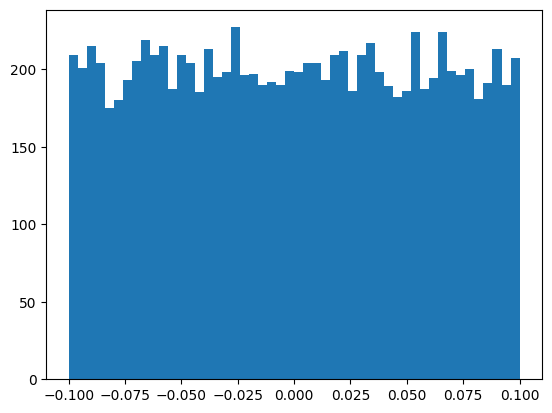

In [4]:
# The default weight distribution, for reference before it is overwritten.
test = classfier()

plt.hist(test.fc1.weight.flatten().detach(), bins=50);

## Managing Data

In [ ]:
# Colab's small MNIST CSV. Normalisation is commented out, so pixels stay 0-255.
data = np.loadtxt("/content/sample_data/mnist_train_small.csv", delimiter=",")

labels = data[:,0]
data = data[:,1:]

# data = data / 255.0

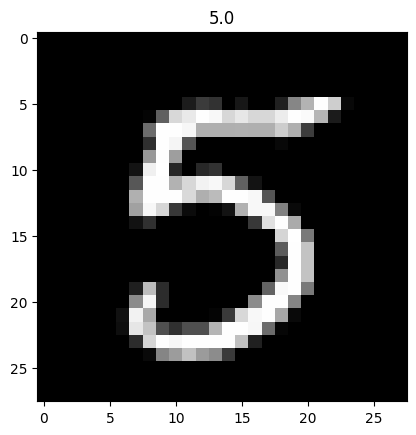

In [ ]:
plt.imshow(data[1].reshape(28,28), cmap='gray');
plt.title(labels[1]);

In [ ]:
# Tensors on GPU, split, loaders.
train_label = torch.tensor(labels, dtype=torch.long, device='cuda')
train_data = torch.tensor(data, dtype=torch.float, device='cuda')

train_data,test_data, train_labels,test_labels = train_test_split(train_data, train_label, test_size=.1)

trainDataSet = TensorDataset(train_data, train_labels)
testDataSet = TensorDataset(test_data, test_labels)

batchsize    = 32
train_loader = DataLoader(trainDataSet,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(testDataSet,batch_size=testDataSet.tensors[0].shape[0])


In [ ]:
# 25 standard deviations from 1e-4 to 10, log-spaced.
std_devs = np.logspace(np.log10(0.0001),np.log10(10), 25)

In [ ]:
# Only fc1's weights are overwritten - one layer, so the effect is isolated.
# torch.randn_like(w) * std draws from N(0, std^2) with the right shape.
# (The commented-out lines would extend this to the input and output layers;
# torch.normal needs a mean argument, which is why they were left out.)
def train_model(loop_count):

  epochs = 10
  lossFunc = nn.CrossEntropyLoss()

  model = classfier()

  # TODO : FIX THIS SHIT ONCE YOU START DOING IT
  # model.input_layer.weight.data = torch.normal(size=model.input_layer.weight.shape,std=std_devs[loop_count])
  model.fc1.weight.data = torch.randn_like(model.fc1.weight) * std_devs[loop_count]
  # model.output_layer.weight.data = torch.normal( size=model.output_layer.weight.shape,std=std_devs[loop_count])

  model.to('cuda')
  lr = 1e-4
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  train_acc = []
  test_acc = []
  losses = []

  for epoch in range(epochs):

    model.train()

    batch_loss = []
    batch_acc = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossFunc(yhat, y)
      batch_loss.append(loss.item())

      # Calculate batch accuracy and append
      batch_acc.append(100 * torch.mean((torch.argmax(yhat, dim=1) == y).float()).cpu())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Print Metrics
    if epoch % 10 == 0 or epoch == epochs - 1:
      print(f'Epoch {epoch}| Std Dev = {np.log10(std_devs[loop_count])} | Loss : {losses[epoch]} | Train Accuracy {train_acc[epoch]:.2f}%.')

    # Test Acc
    model.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      test_acc.append(100 * torch.mean((torch.argmax(model(X), dim=1) == Y).float()).cpu())

  print()
  return train_acc[-1], test_acc[-1]

In [ ]:
# 25 training runs, one per standard deviation.
final_train_acc = []
final_test_acc = []

for i in range(25):
  train_acc , test_acc  = train_model(i)
  final_train_acc.append(train_acc)
  final_test_acc.append(test_acc)

Epoch 0| Std Dev = -4.0 | Loss : 0.9194913498023226 | Train Accuracy 68.78%.
Epoch 9| Std Dev = -4.0 | Loss : 0.09403483000802691 | Train Accuracy 97.28%.

Epoch 0| Std Dev = -3.7916666666666665 | Loss : 0.7426509485974431 | Train Accuracy 77.87%.
Epoch 9| Std Dev = -3.7916666666666665 | Loss : 0.10392693893526585 | Train Accuracy 97.09%.

Epoch 0| Std Dev = -3.5833333333333335 | Loss : 0.7780694310748917 | Train Accuracy 76.93%.
Epoch 9| Std Dev = -3.5833333333333335 | Loss : 0.10072976641532604 | Train Accuracy 97.04%.

Epoch 0| Std Dev = -3.375 | Loss : 0.7146916053393769 | Train Accuracy 78.97%.
Epoch 9| Std Dev = -3.375 | Loss : 0.08864369883626248 | Train Accuracy 97.41%.

Epoch 0| Std Dev = -3.1666666666666665 | Loss : 0.7408589123751557 | Train Accuracy 79.21%.
Epoch 9| Std Dev = -3.1666666666666665 | Loss : 0.09373190210928338 | Train Accuracy 97.22%.

Epoch 0| Std Dev = -2.958333333333333 | Loss : 0.7276576155418815 | Train Accuracy 79.21%.
Epoch 9| Std Dev = -2.9583333333333

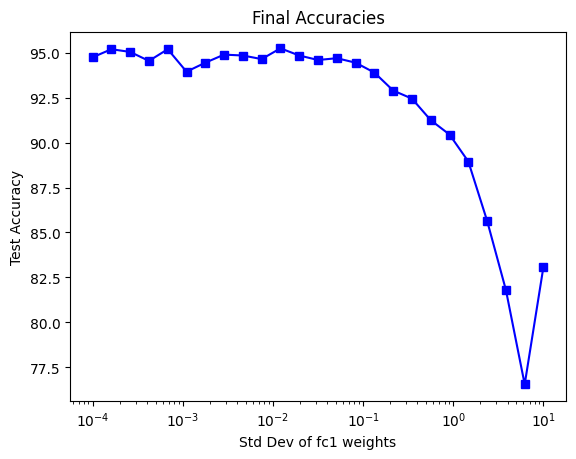

In [ ]:
# Final test accuracy vs initial std, log x-axis.
# Expect a flat plateau up to about 0.1 and a collapse after it. The plateau is
# wide - initialisation scale is forgiving until suddenly it is not.
plt.plot(std_devs, final_test_acc,'bs-')
plt.xscale('log');
plt.xlabel('Std Dev of fc1 weights')
plt.ylabel('Test Accuracy')
plt.title("Final Accuracies");

## Conclusion

This experiment explored the impact of the initial standard deviation of the `fc1` layer's weights on the classification model's performance. The results show that:

*   For small standard deviations (ranging from approximately 0.0001 to 0.01), the model achieves consistently high training and test accuracies (around 99-100% and 95-96% respectively). This indicates that the model is able to learn effectively and generalize well with these initializations.

*   As the standard deviation of the `fc1` layer's weights increases beyond this optimal range, the test accuracy begins to decline significantly, despite the training accuracy often remaining very high (close to 100%). This suggests that very large initial weights in this layer can hinder the model's ability to generalize to unseen data, potentially leading to issues such as exploding gradients, or poor convergence for a generalizable solution, even if it fits the training data well.

In summary, proper initialization of weights, particularly in intermediate layers, is crucial for stable training and achieving good generalization performance in neural networks. There appears to be an optimal range for the standard deviation of the `fc1` layer's initial weights, with values too small or too large negatively impacting test accuracy.